# **SWAP test**

Questo circuito valuta la similarità tra due stati quantistici $\ket{\varphi}, \ket{\psi}$, approssimando la quantità

$$
\lvert\braket{\varphi|\psi}\rvert^2
$$

Useremo un ancilla qubit nello stato $\ket{+}$. La fase di questo qubit verrà invertita con probabilità $\frac{1}{2}$ se gli stati sono ortogonali. Se gli stati sono uguali, la fase non verrà mai invertita. In generale, il rapporto $\frac{\text{misurazioni '0'}}{misurazioni totali}$ è proporzionale alla similarità tra gli stati che si valutano.


## **Circuito test di SWAP**

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from BoredQiskit import FastQiskit as fq
import numpy as np

In [3]:
def swap_test(state1: list, state2: list):
    ancilla = QuantumRegister(1,name="a")
    qr = QuantumRegister(2,name="q")
    cr = ClassicalRegister(1,name="c")
    qc = QuantumCircuit(ancilla,qr,cr)

    qc.initialize(state1,1)
    qc.initialize(state2,2)
    qc.barrier(label="init")

    qc.h(0)
    qc.cswap(0,1,2)
    qc.h(0)
    qc.barrier()

    qc.measure(0,0)
    return qc

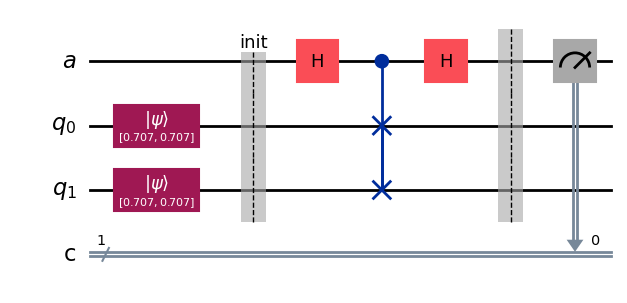

In [4]:
qc = swap_test([1/np.sqrt(2),1/np.sqrt(2)],[1/np.sqrt(2),1/np.sqrt(2)])
qc.draw('mpl')

## **Test di SWAP su stati uguali**

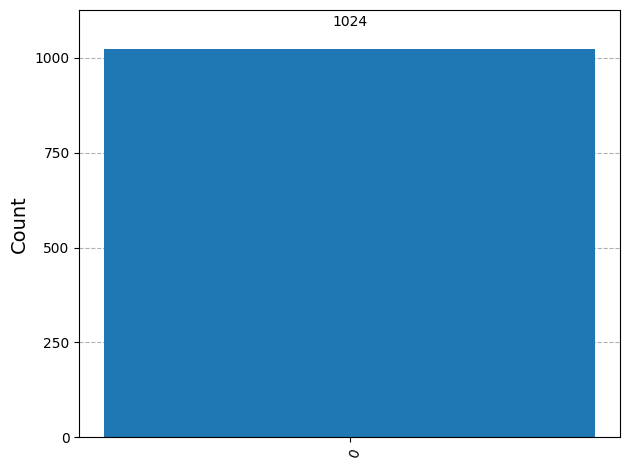

In [5]:
counts = fq.run(qc)
plot_histogram(counts)

## **Test di SWAP su stati ortogonali**

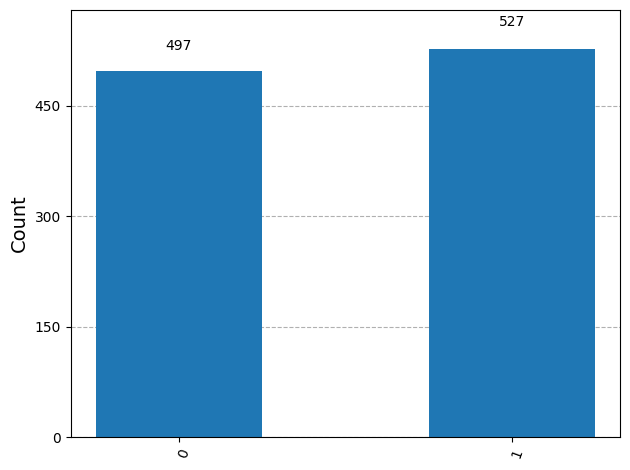

In [6]:
qc = swap_test([1,0], [0,1])
counts = fq.run(qc)
plot_histogram(counts)

## **Test di SWAP su stati simili**

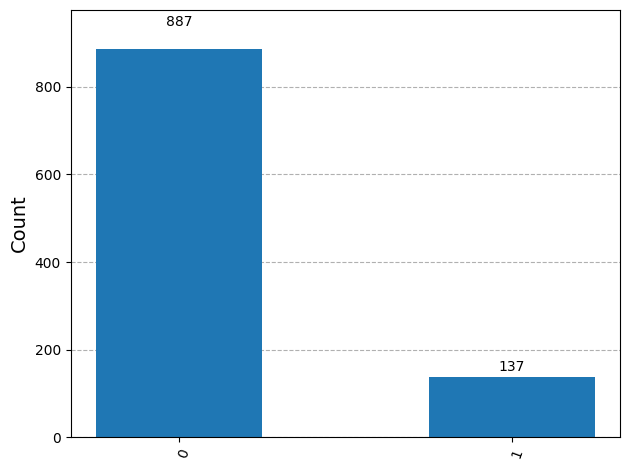

In [7]:
qc = swap_test([1,0], [np.sqrt(3/4),np.sqrt(1/4)])
counts = fq.run(qc)
plot_histogram(counts)

## **Test di SWAP tra input e output di un clonatore approssimato**

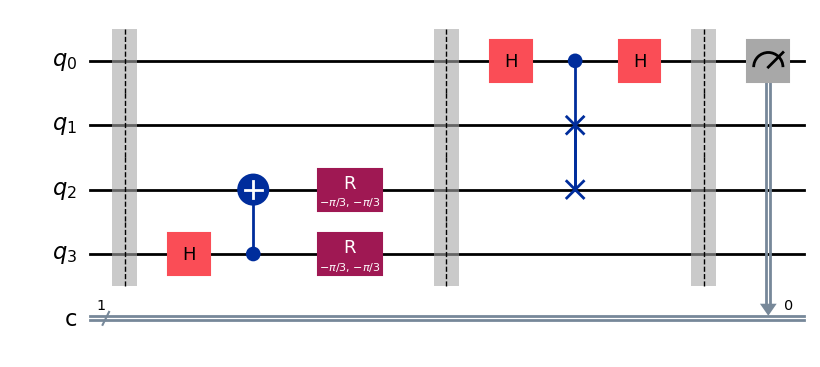

In [8]:
import numpy as np
qc = QuantumCircuit(4,1)
qc.barrier()
qc.h(3)
qc.cx(3,2)
qc.r(-np.pi/3, -np.pi/3,range(2,4))
qc.barrier()
qc.h(0)
qc.cswap(0,1,2)
qc.h(0)
qc.barrier()
qc.measure(0,0)
qc.draw('mpl')

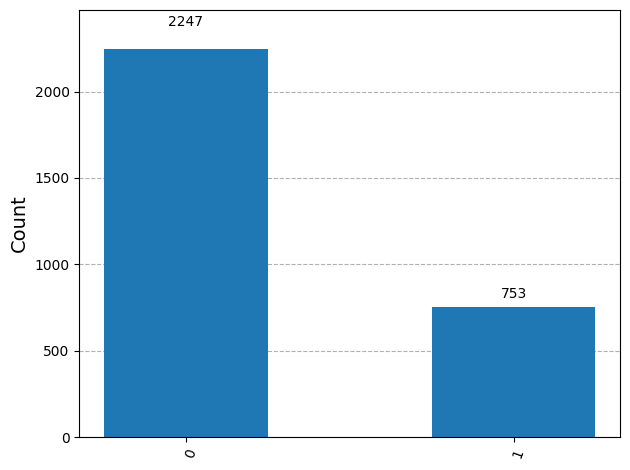

In [9]:
counts = fq.run(qc, 3000)
plot_histogram(counts)